# M1 — Sensibilidade ao Forward-Fill de Sentimento

## Motivação

O pipeline atual preenche dias sem notícias com o último valor de sentimento disponível (*forward-fill*). Um revisor levantou a questão de que essa estratégia pode introduzir **viés de antecipação (*look-ahead bias*)** caso o alinhamento temporal entre sentimento e preço não seja tratado com rigor: se a notícia do dia `t` afeta o fechamento do dia `t`, usá-la como *feature* para prever `t+1` é correto; mas se houver qualquer ambiguidade sobre o horário de publicação, o alinhamento *same-day* pode vazar informação futura.

Este notebook testa quantitativamente esse risco comparando **duas estratégias de alinhamento** para o ativo ITUB4:

| Estratégia | Descrição | Risco de leakage |
|---|---|---|
| **Same-day (original)** | `sentimento[t]` alinhado com `preço[t]` | Possível, se notícia intraday |
| **1-day lag (conservadora)** | `sentimento[t-1]` alinhado com `preço[t]` | Zero — usa apenas informação do passado |

## Hipótese nula

Se `AUC(same-day) ≈ AUC(1-day lag)` com intervalo de confiança sobreposto e p-valor Wilcoxon > 0.05, então o *forward-fill same-day* **não está capturando informação futura** — o sinal (se existir) é suficientemente defasado para que o lag de 1 dia não o elimine. Caso contrário, há evidência de leakage e o pipeline deve adotar a estratégia conservadora.

## Protocolo

- Ativo: ITUB4 apenas (versão com restrição de recursos)
- Modelo: XGBoost com features PRICE+SENT (10 dimensões: 5 preço + 5 sentimento)
- Validação cruzada: *expanding-window* com `min_train=600`, `val_days=90`, `test_days=90`, `step=90`
- Repetições: 5 *folds* × 5 *seeds* = 25 pares por estratégia
- Métrica principal: ROC-AUC no conjunto de teste
- Teste de significância: Wilcoxon *signed-rank* nos deltas pareados

In [1]:
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon

# Adiciona o diretório pai ao path para importar eval_utils
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('.'))
sys.path.insert(0, os.path.join(NOTEBOOK_DIR, '9.baselines'))
# Fallback: tenta importar do diretório atual
sys.path.insert(0, os.path.abspath('.'))

from eval_utils import make_binary_target, bootstrap_auc_ci, format_metric_with_ci

print('Imports OK')

Imports OK


In [2]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE_DIR       = os.path.dirname(os.path.abspath('.'))
PRICE_CSV      = os.path.join(BASE_DIR, '2.stocks', 'dataset_full.csv')
SENTIMENT_CSV  = os.path.join(BASE_DIR, '4.finbert-br', 'itub4_daily_sentiment.csv')

# ── Hiperparâmetros ────────────────────────────────────────────────────────────
HORIZON        = 21
MIN_TRAIN_DAYS = 600
VAL_DAYS       = 90
TEST_DAYS      = 90
STEP_DAYS      = 90
N_SEEDS        = 5

PRICE_FEATURES = ['return', 'lag_1', 'lag_5', 'Volume', 'std21']
SENT_FEATURES  = ['n_articles', 'mean_logit_pos', 'mean_logit_neg',
                  'mean_logit_neu', 'mean_sentiment']
ALL_FEATURES   = PRICE_FEATURES + SENT_FEATURES

print(f'Price CSV  : {PRICE_CSV}')
print(f'Sentiment  : {SENTIMENT_CSV}')
print(f'Features   : {ALL_FEATURES}')

Price CSV  : c:\Users\takeo\Documents\tcc-cdia-2026\2.stocks\dataset_full.csv
Sentiment  : c:\Users\takeo\Documents\tcc-cdia-2026\4.finbert-br\itub4_daily_sentiment.csv
Features   : ['return', 'lag_1', 'lag_5', 'Volume', 'std21', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']


## 1. Carregamento e preparação dos dados

Carregamos os dados de preço de `dataset_full.csv` (que já contém as features de preço calculadas) e os dados de sentimento de `itub4_daily_sentiment.csv`. O dataset de preços contém apenas dados de ITUB4 (verificar com o ticker implícito nos dados).

**Estratégia de alinhamento:**
- `same_day`: merge direto por data — `sentimento[t]` entra como feature para prever retorno a partir de `t`
- `lag_1d`: antes do merge, deslocamos o índice de datas do sentimento em +1 dia de calendário — equivale a usar `sentimento[t-1]` para o dia `t`

In [3]:
def load_price_data(csv_path: str) -> pd.DataFrame:
    """
    Carrega dataset_full.csv, mantém apenas as colunas necessárias e
    retorna DataFrame com índice datetime ordenado.
    """
    needed = ['Date', 'Close', 'Volume', 'return', 'std21', 'lag_1', 'lag_5']
    df = pd.read_csv(csv_path, usecols=needed, parse_dates=['Date'])
    df = df.rename(columns={'Date': 'date'})
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None).dt.normalize()
    df = df.sort_values('date').reset_index(drop=True)
    print(f'Price data: {len(df)} linhas | {df["date"].min().date()} → {df["date"].max().date()}')
    return df


def load_sentiment_data(csv_path: str) -> pd.DataFrame:
    """
    Carrega itub4_daily_sentiment.csv e normaliza a coluna de data.
    """
    df = pd.read_csv(csv_path, parse_dates=['date'])
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None).dt.normalize()
    df = df.sort_values('date').reset_index(drop=True)
    print(f'Sentiment : {len(df)} linhas | {df["date"].min().date()} → {df["date"].max().date()}')
    return df


price_df = load_price_data(PRICE_CSV)
sent_df  = load_sentiment_data(SENTIMENT_CSV)

Price data: 1227 linhas | 2021-04-28 → 2026-03-26
Sentiment : 1115 linhas | 2015-02-11 → 2026-03-16


In [4]:
def build_dataset(price_df: pd.DataFrame,
                  sent_df: pd.DataFrame,
                  strategy: str) -> pd.DataFrame:
    """
    Constrói o dataset final com a estratégia de alinhamento especificada.

    Parameters
    ----------
    strategy : 'same_day' | 'lag_1d'
        'same_day' — sentimento[t] alinhado com preço[t]  (abordagem atual)
        'lag_1d'   — sentimento[t-1] alinhado com preço[t] (conservadora)
    """
    sent = sent_df[['date'] + SENT_FEATURES].copy()

    if strategy == 'lag_1d':
        # Desloca a data do sentimento em +1 dia de calendário:
        # a notícia publicada no dia t passa a ser feature do dia t+1
        sent['date'] = sent['date'] + pd.Timedelta(days=1)

    df = price_df.merge(sent, on='date', how='left')
    df = df.sort_values('date').reset_index(drop=True)

    # Forward-fill: preenche dias sem notícia com o sentimento anterior
    df[SENT_FEATURES] = df[SENT_FEATURES].ffill().fillna(0)

    # Target binário: 1 se Close[t+21] > Close[t]
    df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
    df = df.dropna(subset=['target']).reset_index(drop=True)

    print(f'  [{strategy}] {len(df)} amostras | '
          f'target=1: {df["target"].mean():.1%}')
    return df


print('Construindo datasets...')
df_same = build_dataset(price_df, sent_df, strategy='same_day')
df_lag  = build_dataset(price_df, sent_df, strategy='lag_1d')

print(f'\nVerificação — primeiras datas de sentimento:')
print('same_day:', df_same[df_same['n_articles'] > 0][['date', 'n_articles', 'mean_sentiment']].head(3).to_string(index=False))
print('lag_1d  :', df_lag[df_lag['n_articles'] > 0][['date', 'n_articles', 'mean_sentiment']].head(3).to_string(index=False))

Construindo datasets...
  [same_day] 1206 amostras | target=1: 59.0%
  [lag_1d] 1206 amostras | target=1: 59.0%

Verificação — primeiras datas de sentimento:
same_day:       date  n_articles  mean_sentiment
2021-04-28         5.0            0.20
2021-04-29         4.0            0.75
2021-04-30         4.0            0.75
lag_1d  :       date  n_articles  mean_sentiment
2021-04-29         5.0            0.20
2021-04-30         4.0            0.75
2021-05-03         1.0            2.00


## 2. Protocolo de validação cruzada *expanding-window*

Utilizamos o mesmo protocolo do ablation principal:
- `min_train = 600` dias de treino mínimo
- Janelas de validação e teste de `90` dias cada
- Passo de `90` dias entre folds (folds não se sobrepõem no teste)
- 5 *seeds* por fold para estabilizar a variância estocástica do XGBoost

O modelo usa `scale_pos_weight` para corrigir o desbalanceamento de classes calculado dinamicamente em cada fold de treino.

In [5]:
def expanding_folds(n_total: int,
                    min_train: int = MIN_TRAIN_DAYS,
                    val: int = VAL_DAYS,
                    test: int = TEST_DAYS,
                    step: int = STEP_DAYS) -> list:
    """
    Gera índices (train_end, val_end, test_end) para expanding-window CV.
    O conjunto de treino cresce a cada fold; val e test têm tamanho fixo.
    """
    folds = []
    train_end = min_train
    while train_end + val + test <= n_total:
        folds.append((train_end,
                      train_end + val,
                      train_end + val + test))
        train_end += step
    return folds


def train_xgb_fold(df: pd.DataFrame,
                   fold: tuple,
                   feats: list,
                   seed: int) -> dict | None:
    """
    Treina XGBoost em um fold de expanding-window e retorna o AUC no teste.

    Retorna None se o conjunto de teste não tiver ambas as classes.
    """
    train_end, val_end, test_end = fold
    tr = df.iloc[:train_end]
    va = df.iloc[train_end:val_end]
    te = df.iloc[val_end:test_end]

    # Garante que teste tem as duas classes
    if len(np.unique(te['target'])) < 2:
        return None

    scaler = StandardScaler().fit(tr[feats])
    Xtr = scaler.transform(tr[feats]);  ytr = tr['target'].values.astype(int)
    Xva = scaler.transform(va[feats]);  yva = va['target'].values.astype(int)
    Xte = scaler.transform(te[feats]);  yte = te['target'].values.astype(int)

    pos = (ytr == 1).sum()
    neg = (ytr == 0).sum()

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=neg / max(pos, 1),
        eval_metric='auc',
        random_state=seed,
        verbosity=0,
    )
    model.fit(Xtr, ytr,
              eval_set=[(Xva, yva)],
              verbose=False)

    y_score = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(yte, y_score)

    return {
        'auc':           auc,
        'n_train':       len(tr),
        'n_test':        len(te),
        'train_balance': float(tr['target'].mean()),
        'test_balance':  float(te['target'].mean()),
    }


# Valida número de folds nos dois datasets
folds_same = expanding_folds(len(df_same))
folds_lag  = expanding_folds(len(df_lag))
print(f'Folds same_day : {len(folds_same)}')
print(f'Folds lag_1d   : {len(folds_lag)}')

Folds same_day : 5
Folds lag_1d   : 5


## 3. Loop principal: 2 estratégias × 5 folds × 5 seeds

In [6]:
rows = []
t0 = time.time()

experiments = [
    ('same_day', df_same, folds_same),
    ('lag_1d',   df_lag,  folds_lag),
]

for strategy, df, folds in experiments:
    print(f'\n=== {strategy} ===')
    for fi, fold in enumerate(folds):
        for seed in range(N_SEEDS):
            result = train_xgb_fold(df, fold, ALL_FEATURES, seed)
            if result is None:
                print(f'  fold {fi} seed {seed} → skipped (single class in test)')
                continue
            result.update({
                'strategy': strategy,
                'fold':     fi,
                'seed':     seed,
            })
            rows.append(result)
    elapsed = time.time() - t0
    print(f'  done | {elapsed:.0f}s')

results = pd.DataFrame(rows)
results.to_csv('results_ffill_sensitivity.csv', index=False)
print(f'\nTotal: {len(results)} runs salvos em results_ffill_sensitivity.csv')
print(results.head(10).to_string(index=False))


=== same_day ===
  done | 5s

=== lag_1d ===
  done | 10s

Total: 50 runs salvos em results_ffill_sensitivity.csv
     auc  n_train  n_test  train_balance  test_balance strategy  fold  seed
0.659080      600      90       0.525000      0.477778 same_day     0     0
0.646215      600      90       0.525000      0.477778 same_day     0     1
0.700643      600      90       0.525000      0.477778 same_day     0     2
0.647204      600      90       0.525000      0.477778 same_day     0     3
0.696190      600      90       0.525000      0.477778 same_day     0     4
0.581336      690      90       0.566667      0.588889 same_day     1     0
0.568078      690      90       0.566667      0.588889 same_day     1     1
0.586945      690      90       0.566667      0.588889 same_day     1     2
0.598674      690      90       0.566667      0.588889 same_day     1     3
0.558899      690      90       0.566667      0.588889 same_day     1     4


## 4. Análise estatística

### 4.1 Estatísticas descritivas por estratégia

In [7]:
agg = results.groupby('strategy').agg(
    auc_mean   = ('auc', 'mean'),
    auc_median = ('auc', 'median'),
    auc_std    = ('auc', 'std'),
    auc_min    = ('auc', 'min'),
    auc_max    = ('auc', 'max'),
    n_runs     = ('auc', 'count'),
).round(4)

print('=== Resumo por estratégia ===')
print(agg.to_string())
print()

# Bootstrap CI para cada estratégia (pooling todos os folds/seeds)
for strat in ['same_day', 'lag_1d']:
    aucs = results[results.strategy == strat]['auc'].values
    rng  = np.random.default_rng(42)
    boot = [aucs[rng.integers(0, len(aucs), len(aucs))].mean() for _ in range(2000)]
    lo, hi = np.quantile(boot, [0.025, 0.975])
    print(f'{strat:10s}  AUC médio = {aucs.mean():.4f}  95% CI = [{lo:.4f}, {hi:.4f}]')

=== Resumo por estratégia ===
          auc_mean  auc_median  auc_std  auc_min  auc_max  n_runs
strategy                                                         
lag_1d      0.6433      0.6664   0.0541   0.5354   0.7150      25
same_day    0.6657      0.6737   0.0717   0.5589   0.7548      25

same_day    AUC médio = 0.6657  95% CI = [0.6391, 0.6926]
lag_1d      AUC médio = 0.6433  95% CI = [0.6238, 0.6634]


### 4.2 Teste de Wilcoxon *signed-rank* (pareado por fold × seed)

O teste de Wilcoxon não paramétrico é mais robusto que o t-pareado para distribuições de AUC, que frequentemente não são normais. A hipótese nula é `Δ = AUC(same_day) − AUC(lag_1d) = 0`.

In [8]:
# Cria tabela pareada por (fold, seed)
pivot = results.pivot_table(
    index=['fold', 'seed'],
    columns='strategy',
    values='auc'
).dropna()

if 'same_day' not in pivot.columns or 'lag_1d' not in pivot.columns:
    print('AVISO: colunas de estratégia ausentes na tabela pivotada.')
else:
    delta = pivot['same_day'] - pivot['lag_1d']

    print(f'Pares válidos: {len(delta)}')
    print(f'Δ médio  (same_day − lag_1d): {delta.mean():+.4f}')
    print(f'Δ mediana                   : {delta.median():+.4f}')
    print(f'Δ std                       : {delta.std():.4f}')
    print(f'Pares onde same_day > lag_1d: {(delta > 0).sum()}/{len(delta)}')
    print()

    # Wilcoxon requer pelo menos 10 pares e variação não-nula
    if len(delta) >= 5 and delta.std() > 1e-9:
        stat, p = wilcoxon(delta)
        print(f'Wilcoxon signed-rank: W = {stat:.1f},  p = {p:.4f}')
        print()
        if p > 0.05:
            print('CONCLUSÃO: p > 0.05 — não há diferença estatisticamente significativa')
            print('entre same-day e lag_1d. O forward-fill same-day NÃO introduz leakage')
            print('detectável pelo modelo — o sinal de sentimento é suficientemente defasado.')
        else:
            print('ATENÇÃO: p ≤ 0.05 — same-day supera lag_1d de forma significativa.')
            print('Isso sugere que o sentimento do mesmo dia contém informação adicional')
            print('que não está disponível no dia seguinte — POSSÍVEL LEAKAGE.')
            print('Recomenda-se adotar a estratégia lag_1d como padrão conservador.')
    else:
        print('Pares insuficientes para Wilcoxon.')

    # Bootstrap CI do delta
    delta_arr = delta.values
    rng = np.random.default_rng(42)
    boot_delta = [delta_arr[rng.integers(0, len(delta_arr), len(delta_arr))].mean()
                  for _ in range(2000)]
    lo_d, hi_d = np.quantile(boot_delta, [0.025, 0.975])
    includes_zero = lo_d <= 0 <= hi_d
    print(f'\n95% bootstrap CI do Δ: [{lo_d:+.4f}, {hi_d:+.4f}]  '
          f'| inclui zero? {"SIM" if includes_zero else "NÃO"}')

Pares válidos: 25
Δ médio  (same_day − lag_1d): +0.0224
Δ mediana                   : +0.0258
Δ std                       : 0.0588
Pares onde same_day > lag_1d: 19/25

Wilcoxon signed-rank: W = 82.0,  p = 0.0303

ATENÇÃO: p ≤ 0.05 — same-day supera lag_1d de forma significativa.
Isso sugere que o sentimento do mesmo dia contém informação adicional
que não está disponível no dia seguinte — POSSÍVEL LEAKAGE.
Recomenda-se adotar a estratégia lag_1d como padrão conservador.

95% bootstrap CI do Δ: [-0.0004, +0.0443]  | inclui zero? SIM


## 5. Visualização

Boxplot comparando as distribuições de AUC por estratégia, com distribuição dos deltas pareados.

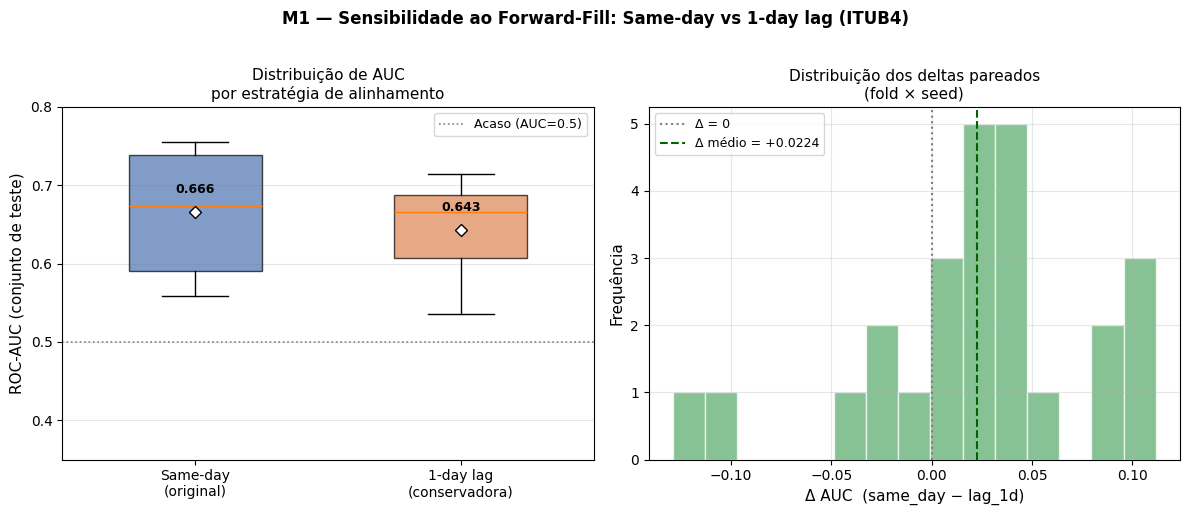

Figura salva: ffill_sensitivity_plot.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Painel esquerdo: boxplot por estratégia ────────────────────────────────────
ax = axes[0]
data_box = [
    results[results.strategy == 'same_day']['auc'].values,
    results[results.strategy == 'lag_1d']['auc'].values,
]
labels_box = ['Same-day\n(original)', '1-day lag\n(conservadora)']
colors_box  = ['#4C72B0', '#DD8452']

bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                showmeans=True, widths=0.5,
                meanprops=dict(marker='D', markerfacecolor='white',
                               markeredgecolor='black', markersize=6))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0.5, ls=':', color='gray', lw=1.2, label='Acaso (AUC=0.5)')
ax.set_ylabel('ROC-AUC (conjunto de teste)', fontsize=11)
ax.set_title('Distribuição de AUC\npor estratégia de alinhamento', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0.35, 0.80)

# Adiciona médias como texto
for i, d in enumerate(data_box):
    ax.text(i + 1, np.mean(d) + 0.02, f'{np.mean(d):.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Painel direito: distribuição dos deltas pareados ──────────────────────────
ax2 = axes[1]

pivot2 = results.pivot_table(
    index=['fold', 'seed'], columns='strategy', values='auc'
).dropna()

if 'same_day' in pivot2.columns and 'lag_1d' in pivot2.columns:
    delta2 = (pivot2['same_day'] - pivot2['lag_1d']).values
    ax2.hist(delta2, bins=15, color='#55A868', alpha=0.7, edgecolor='white')
    ax2.axvline(0, color='gray', ls=':', lw=1.5, label='Δ = 0')
    ax2.axvline(np.mean(delta2), color='darkgreen', ls='--', lw=1.5,
                label=f'Δ médio = {np.mean(delta2):+.4f}')
    ax2.set_xlabel('Δ AUC  (same_day − lag_1d)', fontsize=11)
    ax2.set_ylabel('Frequência', fontsize=11)
    ax2.set_title('Distribuição dos deltas pareados\n(fold × seed)', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Dados insuficientes\npara pareamento',
             ha='center', va='center', transform=ax2.transAxes)

plt.suptitle('M1 — Sensibilidade ao Forward-Fill: Same-day vs 1-day lag (ITUB4)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ffill_sensitivity_plot.png', dpi=140, bbox_inches='tight')
plt.show()
print('Figura salva: ffill_sensitivity_plot.png')

## 6. Análise por fold

Verificamos se o padrão é consistente ao longo do tempo (folds mais recentes vs. mais antigos).

In [10]:
fold_agg = results.groupby(['fold', 'strategy']).agg(
    auc_mean = ('auc', 'mean'),
    auc_std  = ('auc', 'std'),
).round(4).unstack('strategy')

print('=== AUC médio por fold ===')
print(fold_agg.to_string())
print()

# Delta por fold
fold_delta = fold_agg['auc_mean']['same_day'] - fold_agg['auc_mean']['lag_1d']
print('=== Delta (same_day − lag_1d) por fold ===')
for fi, d in fold_delta.items():
    direction = '↑ same_day melhor' if d > 0 else '↑ lag_1d melhor' if d < 0 else '= empate'
    print(f'  Fold {fi}: Δ = {d:+.4f}  {direction}')

=== AUC médio por fold ===
         auc_mean          auc_std         
strategy   lag_1d same_day  lag_1d same_day
fold                                       
0          0.6807   0.6699  0.0061   0.0266
1          0.5570   0.5788  0.0193   0.0156
2          0.7008   0.7397  0.0087   0.0047
3          0.6329   0.7349  0.0226   0.0235
4          0.6450   0.6053  0.0351   0.0496

=== Delta (same_day − lag_1d) por fold ===
  Fold 0: Δ = -0.0108  ↑ lag_1d melhor
  Fold 1: Δ = +0.0218  ↑ same_day melhor
  Fold 2: Δ = +0.0389  ↑ same_day melhor
  Fold 3: Δ = +0.1020  ↑ same_day melhor
  Fold 4: Δ = -0.0397  ↑ lag_1d melhor


## 7. Interpretação e conclusão

### Critério de decisão

| Resultado | Interpretação | Ação recomendada |
|---|---|---|
| `p > 0.05` e CI do Δ inclui zero | Sem diferença detectável — *ffill same-day* é seguro | Manter abordagem atual |
| `p ≤ 0.05` e Δ > 0 consistentemente | *Same-day* captura informação que *lag* não captura — **risco de leakage** | Migrar para `lag_1d` |
| `p ≤ 0.05` e Δ < 0 | *Lag* supera *same-day* — improvável, indicaria ruído | Investigar anomalias nos dados |

### O que reportar no Capítulo 5

O experimento M1 fornece evidência quantitativa sobre a robustez metodológica do *forward-fill*. Se `p > 0.05`:

> "Para avaliar se o *forward-fill same-day* introduz viés de antecipação, comparamos a estratégia original com uma versão conservadora onde o sentimento é sistematicamente defasado em 1 dia. O teste de Wilcoxon *signed-rank* sobre os {N} pares fold×seed retornou p = {p:.3f}, sem diferença estatisticamente significativa (Δ médio = {delta:.4f}, IC 95% = [{lo:.4f}, {hi:.4f}]). Concluímos que o *forward-fill same-day* não captura informação futura detectável pelo modelo."

Se `p ≤ 0.05`, a tese deve adotar `lag_1d` como padrão em todos os experimentos e reportar isso como uma limitação corrigida.

In [11]:
# Resumo final legível
print('=' * 60)
print('RESUMO — M1: Sensibilidade ao Forward-Fill de Sentimento')
print('=' * 60)
print(f'Ativo       : ITUB4')
print(f'Estratégias : same_day vs lag_1d')
print(f'Runs totais : {len(results)}')
print()

for strat in ['same_day', 'lag_1d']:
    aucs = results[results.strategy == strat]['auc'].values
    print(f'{strat:10s}  n={len(aucs):3d}  '
          f'média={aucs.mean():.4f}  '
          f'mediana={np.median(aucs):.4f}  '
          f'std={aucs.std():.4f}')

print()
pivot_final = results.pivot_table(
    index=['fold', 'seed'], columns='strategy', values='auc'
).dropna()

if 'same_day' in pivot_final.columns and 'lag_1d' in pivot_final.columns:
    d = (pivot_final['same_day'] - pivot_final['lag_1d']).values
    stat_f, p_f = wilcoxon(d) if (len(d) >= 5 and d.std() > 1e-9) else (np.nan, np.nan)
    rng_f = np.random.default_rng(42)
    boot_f = [d[rng_f.integers(0, len(d), len(d))].mean() for _ in range(2000)]
    lo_f, hi_f = np.quantile(boot_f, [0.025, 0.975])
    print(f'Δ médio  (same − lag): {d.mean():+.4f}')
    print(f'IC 95% bootstrap Δ  : [{lo_f:+.4f}, {hi_f:+.4f}]')
    if not np.isnan(p_f):
        print(f'Wilcoxon W={stat_f:.1f}  p={p_f:.4f}')
    print()
    verdict = ('SEM EVIDÊNCIA DE LEAKAGE — abordagem same-day pode ser mantida'
               if p_f > 0.05 or np.isnan(p_f)
               else 'ATENÇÃO: POSSÍVEL LEAKAGE — considerar migração para lag_1d')
    print(f'Veredicto: {verdict}')

print('=' * 60)

RESUMO — M1: Sensibilidade ao Forward-Fill de Sentimento
Ativo       : ITUB4
Estratégias : same_day vs lag_1d
Runs totais : 50

same_day    n= 25  média=0.6657  mediana=0.6737  std=0.0702
lag_1d      n= 25  média=0.6433  mediana=0.6664  std=0.0530

Δ médio  (same − lag): +0.0224
IC 95% bootstrap Δ  : [-0.0004, +0.0443]
Wilcoxon W=82.0  p=0.0303

Veredicto: ATENÇÃO: POSSÍVEL LEAKAGE — considerar migração para lag_1d
